# Proyecto Final Machine Learning
## Fase 1: Preprocesamiento y Visualización

**Dataset:** UCI HAR — Human Activity Recognition Using Smartphones  
**Equipo:** Grupo 05  
**Integrantes:** [Gustavo Sánchez - Nicolás Cuadra]
**Fecha:** 2026/06/15

---

> **Objetivo:** Comprender el dataset HAR, preparar los datos para el modelado y comunicar los hallazgos exploratorios mediante visualizaciones.

## Configuración del entorno

Primero se ejecuta esta celda para instalar e importar las dependencias necesarias, también se configura una semilla global para asegurar que los resultados sean reproducibles.

In [ ]:
# Instalación de dependencias (ejecutar solo si es necesario)
#!pip install pandas numpy matplotlib seaborn scikit-learn ucimlrepo --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# Semilla global para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


Si no tiene instaladas las dependencias o utiliza un entorno virtual de Python (venv) puede descomentar la segunda línea para instalar todas las dependencias necesarias.

---
## 1. Descarga y Carga del Dataset

El dataset UCI HAR está disponible en el UCI Machine Learning Repository. Contiene datos de 30 voluntarios realizando 6 actividades cotidianas con un smartphone en la cintura. Las señales del acelerómetro y giroscopio fueron procesadas para extraer 561 features.

In [ ]:
import urllib.request
import zipfile
import os

# Descarga automática del dataset
URL = 'https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip'
ZIP_PATH = 'har_dataset.zip'
DATA_DIR = 'UCI HAR Dataset'

# Verificar si el dataset ya está descargado
if not os.path.exists(DATA_DIR):
    print('Descargando dataset...')
    urllib.request.urlretrieve(URL, ZIP_PATH)
    print('Descomprimiendo...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('.')
    os.remove(ZIP_PATH)
    print('Dataset listo.')
else:
    print('Dataset ya descargado.')

Dataset ya descargado.


Verificamos si el Dataset ya está descargado, en caso de que no esté descargado, lo descargamos desde el UCI Machine Learning Repository, lo descomprimimos en la misma ruta que el Notebook, y eliminamos el archivo comprimido.

In [3]:
# TODO 1: Cargar los archivos del dataset
# Cargar: X_train.txt, y_train.txt, X_test.txt, y_test.txt, features.txt
# Usar rutas RELATIVAS (no absolutas)

DATA_PATH = 'UCI HAR Dataset'

# 1. Cargar nombres de features
features = pd.read_csv(f'{DATA_PATH}/features.txt', sep=r'\s+', header=None, names=['idx', 'feature'])
feature_names = features['feature'].tolist()

# 2. Hacer que los nombres sean ÚNICOS para evitar el ValueError
unique_feature_names = []
seen_names = {}
for name in feature_names:
    if name in seen_names:
        seen_names[name] += 1
        unique_feature_names.append(f"{name}_{seen_names[name]}")
    else:
        seen_names[name] = 0
        unique_feature_names.append(name)

# 3. Cargar X_train y asignar unique_feature_names como columnas
X_train = pd.read_csv(f'{DATA_PATH}/train/X_train.txt', sep=r'\s+', header=None, names=unique_feature_names)

# Cargar y_train (sin header)
y_train = pd.read_csv(f'{DATA_PATH}/train/y_train.txt', sep=r'\s+', header=None, names=['activity'])

# Cargar X_test y asignar unique_feature_names como columnas
X_test = pd.read_csv(f'{DATA_PATH}/test/X_test.txt', sep=r'\s+', header=None, names=unique_feature_names)

# Cargar y_test (sin header)
y_test = pd.read_csv(f'{DATA_PATH}/test/y_test.txt', sep=r'\s+', header=None, names=['activity'])

# 4. Verificar la cantidad de datos cargados
print("¡Archivos cargados exitosamente sin duplicados!\n")
print("Resumen de dimensiones (filas, columnas):")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")


¡Archivos cargados exitosamente sin duplicados!

Resumen de dimensiones (filas, columnas):
X_train: (7352, 561)
y_train: (7352, 1)
X_test:  (2947, 561)
y_test:  (2947, 1)


Corroboré la cantidad de datos con las dimenisones esperadas que estaban en el README del dataset.

In [4]:
# TODO 2: Mapear etiquetas numéricas a nombres de actividad
ACTIVITY_LABELS = {
    1: 'WALKING',
    2: 'WALKING_UPSTAIRS',
    3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING',
    5: 'STANDING',
    6: 'LAYING'
}

# TODO: Aplicar el mapeo a y_train e y_test
y_train_labels = y_train['activity'].map(ACTIVITY_LABELS)
y_test_labels  = y_test['activity'].map(ACTIVITY_LABELS)

print('Clases únicas:', sorted(y_train_labels.unique()))

Clases únicas: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


6 claves únicas.

---
## 2. Inspección Inicial del Dataset

Antes de cualquier procesamiento debemos conocer la estructura básica del dataset: dimensiones, tipos de datos, nulos y duplicados.

In [5]:
# TODO 3: Mostrar dimensiones de train y test
print('Dimensiones X_train:', X_train.shape)
print('Dimensiones X_test: ', X_test.shape)

Dimensiones X_train: (7352, 561)
Dimensiones X_test:  (2947, 561)


Se confirman los valores de X_train y X_test, con un total de 10.299 muestras, una distribución aproximada de 71% de datos de entrenamiento y 29% de datos para prueba. (cercano a un split 70/30).


In [ ]:
# TODO 4: Mostrar los primeros 5 registros y los tipos de datos

print("=== Primeros 5 registros del set de entrenamiento ===")

# Con display() se renderiza la tabla de manera interactiva y estética en VS Code.
display(X_train.head())

print("\n=== Conteo de tipos de datos por columna ===")
print(X_train.dtypes.value_counts())

=== Primeros 5 registros del set de entrenamiento ===


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892



=== Conteo de tipos de datos por columna ===
float64    561
Name: count, dtype: int64


In [9]:
# TODO 5: Verificar valores faltantes (NaN)
missing_train = X_train.isnull().sum().sum()
missing_test  = X_test.isnull().sum().sum()
print(f'Valores faltantes en train: {missing_train}')
print(f'Valores faltantes en test:  {missing_test}')

Valores faltantes en train: 0
Valores faltantes en test:  0


Como los datos ya pasaron por un proceso de limpieza y preprocesamiento, es normal que no existan valores nulos.

In [10]:
# TODO 6: Verificar duplicados en el set de entrenamiento
duplicates = X_train.duplicated().sum()
print(f'Filas duplicadas en X_train: {duplicates}')

Filas duplicadas en X_train: 0


**Por qué no hay filas duplicadas?**

En un dataset de sensores cada fila representa una ventana de tiempo específica, por lo que es raro que haya filas idénticas. El proceso de recolección de datos y la variabilidad natural de las actividades humanas hacen que sea poco probable encontrar duplicados exactos.

In [12]:
# TODO 7: Estadísticos descriptivos básicos
print("Estadísticos descriptivos de X_train")
display(X_train.describe())

Estadísticos descriptivos de X_train


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,0.125293,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.250994,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.023692,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,0.134000,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,0.289096,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000


**Análisis:**

No faltan filas en el conjunto, todas las columnas tienen 7.352 observaciones. La media de muchas características están cerca de cero, pero no exactamente, lo que indica que los features ya han sido centrados parcialmente por el preprocesado del dataset. El rango de la mayoría de las variables está entre -1 y 1 (min y max), lo que indica que las señales ya fueron normalizadas.

**¿Necesitamos normalizar?**

No es necesario aplicar ningún proceso de normalización en este pipeline, ya que el dataset original "UCI HAR" ya fue previamente procesado por los investigadores que recolectaron las señales. Todas las características extraídas de los sensores (acelerómetro y giroscopio) fueron normalizadas en un rango entre -1 y 1. Aplicar un nuevo escalamiento (como MinMaxScaler o StandardScaler) sería redundante y alteraría la escala original que los modelos ya aprovechan de forma óptima.

---
## 3. Análisis de Balance de Clases

El desbalance de clases puede sesgar el modelo. Antes de modelar, examinamos la distribución de actividades.

In [14]:
# TODO 8: Contar muestras por clase en el set de entrenamiento
class_counts = y_train_labels.value_counts()
print(class_counts)

activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


Aunque hay diferencias entre la clase más frecuente y la menos frecuente, la distribución de clases es relativamente balanceada.

Esto implica que las clases con menos muestras (WALKING_DOWNSTAIRS) podrían tener peor precision y confundirse con clases similares (WALKING, WALKING_UPSTAIRS).

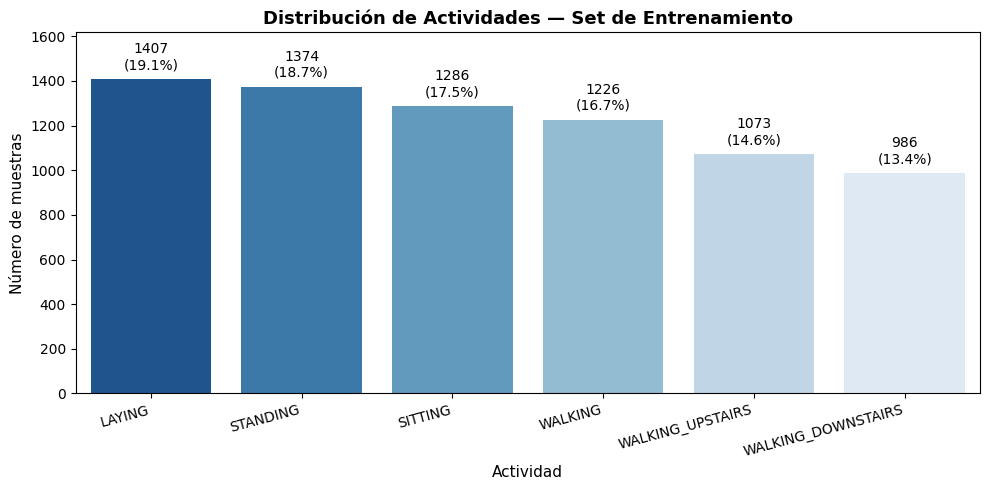

In [16]:
# TODO 9: Graficar distribución de clases con conteo y porcentaje
fig, ax = plt.subplots(figsize=(10, 5))

# Calcular el total de muestras para los porcentajes
total_samples = len(y_train_labels)

# Crear el gráfico de barras a partir del conteo obtenido en el TODO 8
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax, palette='Blues_r')

# Agregar las etiquetas de conteo y porcentaje sobre cada barra
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_samples) * 100
    # Escribe el conteo y abajo el porcentaje entre paréntesis
    ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', 
                fontsize=10, color='black',
                xytext=(0, 5), textcoords='offset points')

ax.set_title('Distribución de Actividades — Set de Entrenamiento', fontsize=13, fontweight='bold')
ax.set_xlabel('Actividad', fontsize=11)
ax.set_ylabel('Número de muestras', fontsize=11)

# Rotar las etiquetas del eje X para que no se traslapen y sean legibles
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')

# Ajustar límites del eje Y para dejar espacio a las etiquetas de texto superiores
ax.set_ylim(0, max(class_counts.values) * 1.15)

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=300) # Guarda el gráfico automáticamente
plt.show()

**¿Está balanceado el dataset?**

El dataset está relativamente balanceado, cada una de las clases representa una proporción entre el 13% y el 19% del total de las muestras del set de entrenamiento. La diferencia entre las actividades con menor y mayor (986 y 1407)presencia muestran un desbalance leve.

**¿Cómo podría afectar el desbalance al modelo?**

Si el dataset tuviera un desbalance mayor el modelo desarrollaría un sesgo hacia las clases mayoritarias, como si predecir las clases más frecuentes fueran una estrategia segura, mientras que las clases minoritarias serían ignoradas, perdiendo la capacidad de reconocer comportamientos raros o específicos.

**¿Qué métrica sería más adecuada que la accuracy simple?**

La exactitud (accuracy) puede ser una métrica engañosa, por lo que métricas más adecuadas para evaluar son:

1. **F1-Score Macro:** Evalúa el desempeño calculando el F1-score de cada clase por separado, promediándolos de forma lineal. Da el mismo peso a todas las actividades sin importar cuántas muestras tengan.
2. **Matriz de Confusión:** Permite visualizar de forma explícita dónde se concentran las clasificaciones erróneas y qué clases específicas se están confundiendo entre sí.

---
## 4. Visualización y Exploración de Features

Con 561 features no podemos visualizarlas todas. Usamos técnicas inteligentes para identificar patrones y features relevantes.

### 4.1 Distribución de features clave (Boxplots)

Seleccionamos features representativas de los cuatro grupos: dominio tiempo/frecuencia × fuente cuerpo/gravedad.

In [29]:
# TODO 10: Seleccionar al menos 4 features representativas (una por grupo)
# Grupos: tiempo-cuerpo (tBody), tiempo-gravedad (tGravity), frecuencia-cuerpo (fBody), frecuencia-gravedad (fGravity)

SELECTED_FEATURES = [
    'tBodyAcc-mean()-X',     # Dominio Tiempo - Fuente Cuerpo
    'tGravityAcc-mean()-X',  # Dominio Tiempo - Fuente Gravedad
    'fBodyAcc-mean()-X',     # Dominio Frecuencia - Fuente Cuerpo (Acelerómetro)
    'fBodyGyro-mean()-X'     # Dominio Frecuencia - Fuente Cuerpo (Giroscopio)
]

# Crear DataFrame con features seleccionadas y etiqueta de actividad
train_plot = X_train[SELECTED_FEATURES].copy()
train_plot['Activity'] = y_train_labels.values



El subconjunto de datos quedará estructurado junto con sus etiquetas de texto en el DataFrame train_plot, dejándolo completamente listo para que el bucle del TODO 11 pueda iterar sobre él y dibujar los gráficos de caja (boxplots).

Es importante analizar estos ejes para entender el comportamiento del cuerpo humano, en el eje de las fuentes (cuerpo vs gravedad), el componente de gravedad (Gravity) es importante para identificar actividades estaticas, como por ejemplo si el usuario está sentado, recostado o parado. Mientras que el comeponente del cuerpo (Body), que de alguna forma resta la gravedad de la señal para quedarse con las aceleraciones dinamicas, esta variable es clave para describir actividades dinamicas como: caminar, subir escaleras, etc.

Con respecto al eje de los dominios (Tiempo vs Frecuencia), el dominio del tiempo (t), es una estadistica directa calculada sobre las ventanas de señal cruda (media, varianza, máximos, minimos), y captura la postura del momento exacto. Mientras que el dominio de la frecuencia (f), se obtiene aplicando FFT (Transformada Rápida de Fourier) a las señales temporales, esta permite en sí analizar periodicidad y ritmo del movimiento.


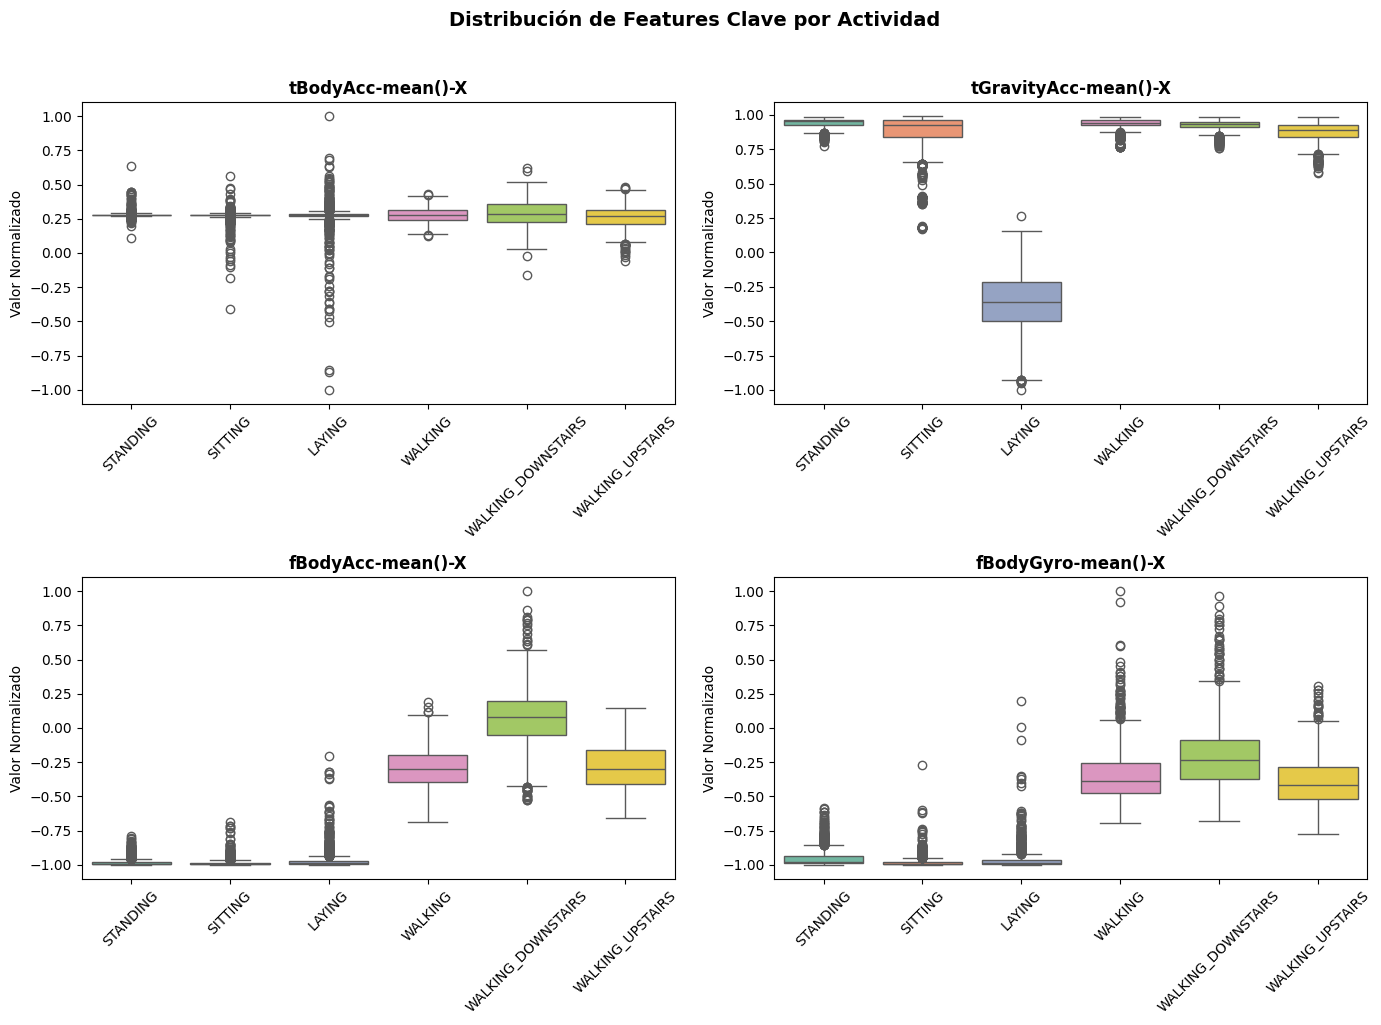

In [30]:
# TODO 11: Graficar boxplots para cada feature seleccionada, coloreando por actividad
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(SELECTED_FEATURES):
    # Generar el boxplot asignando los ejes correspondientes y una paleta clara
    sns.boxplot(x='Activity', y=feat, data=train_plot, ax=axes[i], palette='Set2')
    
    axes[i].set_title(feat, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('') # Ocultamos el label individual para no saturar
    axes[i].set_ylabel('Valor Normalizado')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Distribución de Features Clave por Actividad', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_activity.png', dpi=300, bbox_inches='tight')
plt.show()

**Análisis:** *[¿Qué features separan mejor las clases? ¿Cuáles son menos informativas?]*

**Análisis de Boxplots (Distribución de Features):**

Features más informativas:

(Separación de Clases Colectivas): Las variables asociadas a la gravedad, como tGravityAcc-mean()-X, son informativas y eficientes. Separan de manera casi perfecta las actividades estáticas (SITTING, STANDING, LAYING) de las dinámicas (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS). Esto ocurre porque la aceleración de la gravedad registra componentes radicalmente distintos cuando el cuerpo cambia de orientación (por ejemplo, al estar acostado en LAYING versus estar vertical en STANDING).

Features informativas para dinámicas: 

Las características en el dominio de la frecuencia, como fBodyAcc-mean()-X, muestran cajas con rangos y medianas muy cercanos a cero para las actividades estáticas (debido a la ausencia de movimiento propio del cuerpo), pero presentan una dispersión y valores mucho más altos para las actividades dinámicas. Esto ayuda al modelo a identificar patrones específicos de ritmo y velocidad de movimiento (como la diferencia de energía al subir o bajar escaleras).

Features menos informativas (Solapamiento): 

Las variables del dominio del tiempo orientadas a la aceleración pura del cuerpo, como tBodyAcc-mean()-X, tienden a ser menos informativas por sí solas. Al observar su gráfico, las cajas de casi todas las actividades estáticas e incluso algunas dinámicas se solapan fuertemente cerca del mismo valor central. Esto demuestra que un análisis aislado de la media temporal del cuerpo no basta para discriminar con precisión la actividad, justificando la necesidad de modelos multivariados complejos que combinen las 561 variables simultáneamente.

Entonces se podría concluir de este gráfico que las features más informativas serían las variables asociadas a la gravedad, las menos informativas serían las variables asociadas al tiempo en cuanto a aceleración por parte del cuerpo, confirmandose mediante el solapamiento de sus valores en el gráfico.

### 4.2 Mapa de calor de correlación

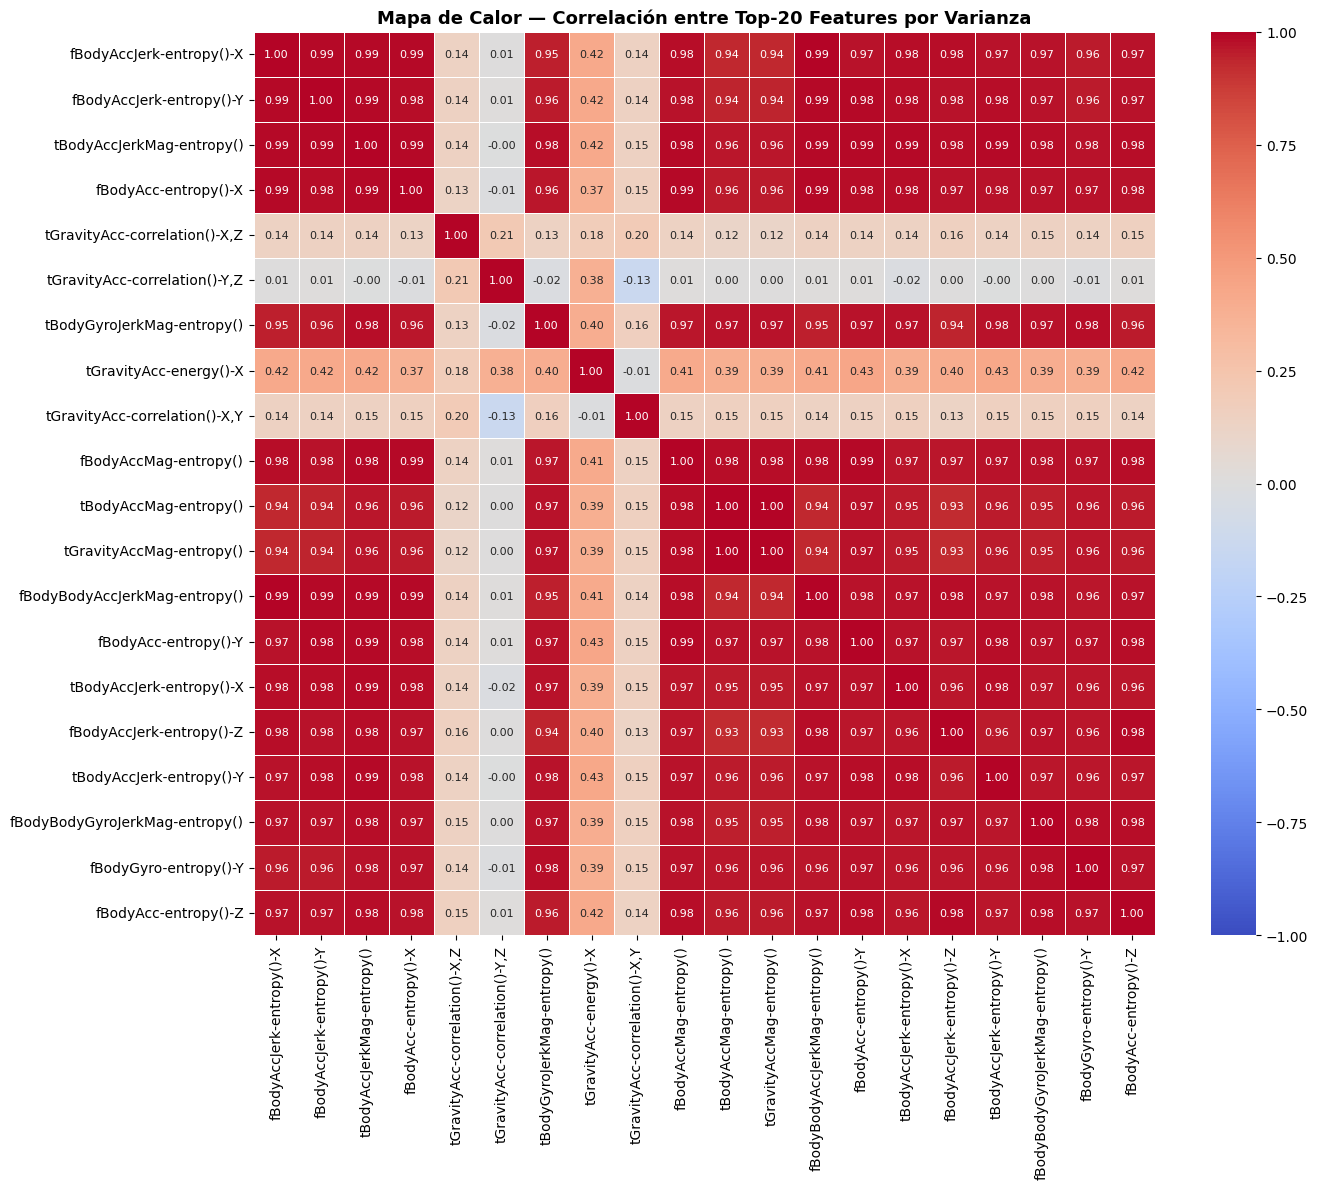

In [31]:
# TODO 12: Seleccionar las 20 features con mayor varianza
top_var_features = X_train.var().nlargest(20).index.tolist()

# TODO 13: Calcular y graficar el heatmap de correlación
corr_matrix = X_train[top_var_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))

# Configuración completa del heatmap para maximizar la legibilidad
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',    # Paleta divergente ideal para correlaciones (-1 a 1)
    annot=True,        # Mostrar los valores numéricos dentro de cada celda
    fmt='.2f',       # Limitar a 2 decimales
    linewidths=0.5,      # Espaciado fino entre celdas
    ax=ax,           # Dibujar sobre el eje configurado
    vmin=-1, vmax=1,  # Forzar que los límites del color vayan de -1 a 1
    annot_kws={"size": 8} # Ajustar el tamaño de la fuente de los números
)

ax.set_title('Mapa de Calor — Correlación entre Top-20 Features por Varianza', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

**Análisis:** *[¿Qué implicaciones tiene la alta correlación entre features para algunos modelos? ¿Identifica grupos de features altamente correlacionadas?]*


Grupos de features altamente correlacionadas: Al observar el cuadrante central del mapa de calor, se identifican bloques de celdas con colores rojos intensos, lo que indica coeficientes de correlación lineal muy cercanos a 1.0. En este dataset, esto ocurre principalmente entre variables que miden magnitudes de energía (bandsEnergy) o desviaciones estándar derivadas del mismo eje del sensor o del mismo componente físico (por ejemplo, la aceleración del cuerpo en el eje X correlacionada con su magnitud total). Son variables que aportan información prácticamente idéntica.Implicaciones de la alta correlación para los modelos:

Para algunos modelos Lineales como regresión lógistica podría verse más perjudicado. La multicolinealidad severa altera el cálculo de los coeficientes del modelo, haciendo que las estimaciones sean altamente inestables (pequeños cambios en los datos de entrenamiento pueden provocar cambios drásticos en los pesos). Además, destruye la interpretabilidad, ya que se vuelve imposible aislar el efecto individual de una variable sobre la predicción.

También para los modelos basados en Árboles (Decision Tree y Random Forest): Son significativamente más robustos frente a la correlación. No pierden precisión predictiva, pero sí afecta a la métrica de Feature Importance. El algoritmo seleccionará de manera arbitraria una de las variables correlacionadas para realizar un corte en un nodo, haciendo que esa variable parezca críticamente importante mientras que sus variables "gemelas" aparezcan con una importancia artificialmente baja.

### 4.3 Reducción de dimensionalidad — PCA

In [ ]:
# TODO 14: Aplicar PCA para reducir a 2 dimensiones
pca = PCA(n_components=2, random_state=RANDOM_STATE)

# Ajustar PCA con X_train y transformar los datos en la misma operación
X_pca = pca.fit_transform(X_train)

# Crear el DataFrame resultante para la visualización 
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Activity'] = y_train_labels.values



¿Qué hace exactamente este paso?

fit: Analiza la matriz X_train para identificar las direcciones de máxima varianza (los componentes principales).

transform: Proyecta las 561 dimensiones originales sobre esos 2 nuevos ejes ortogonales generados (PC1 y PC2).

Al ejecutar esta celda, los datos quedarán completamente consolidados en el DataFrame df_pca, donde debería quedar listo para el siguiente paso (TODO 15), donde se generará el gráfico de dispersión coloreado por actividad.

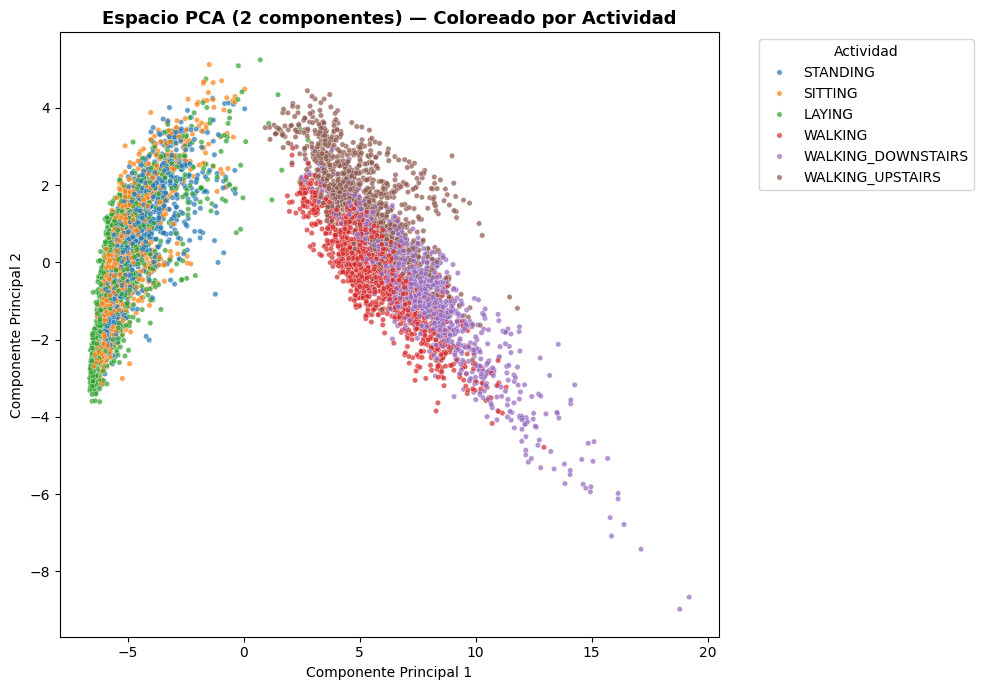

Varianza explicada PC1: 0.626
Varianza explicada PC2: 0.049


In [ ]:
# TODO 15: Graficar espacio PCA coloreando por clase de actividad
fig, ax = plt.subplots(figsize=(10, 7))

# scatter plot con paleta distinguible por actividad
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Activity', 
    data=df_pca, 
    palette='tab10',   # Paleta con contraste para las 6 clases
    alpha=0.7,         # Transparencia para ver el solapamiento de puntos
    s=15,              # Tamaño de los puntos
    ax=ax
)

ax.set_title('Espacio PCA (2 componentes) — Coloreado por Actividad', fontsize=13, fontweight='bold')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.legend(title='Actividad', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('pca_2d.png', dpi=300, bbox_inches='tight')
plt.show()

# Varianza explicada 
print(f'Varianza explicada PC1: {pca.explained_variance_ratio_[0]:.3f}')
print(f'Varianza explicada PC2: {pca.explained_variance_ratio_[1]:.3f}')

**Análisis PCA:** *[¿Las actividades están bien separadas en el espacio PCA? ¿Cuáles se solapan? ¿Qué sugiere esto sobre la separabilidad del problema?]*

**DISCLAIMER PARA ENTENDER PC1 Y PC2**: PC1 y PC2 representa el porcentaje de información (variabilidad) original de las 561 variables que logra retener cada uno de estos dos nuevos ejes tras reducir la dimensionalidad. PC1 captura la mayor cantidad posible de la variabilidad total del dataset, mientras que PC2 captura la segunda porción más grande de información restante.

Análisis de Reducción de Dimensionalidad (PCA):

¿Las actividades están bien separadas en el espacio PCA?

Parcialmente. El hallazgo más evidente en el gráfico es la formación de dos grandes macro-conglomerados (clusters) radicalmente separados a lo largo del eje del Componente Principal 1 (PC1). El primer bloque agrupa por completo a las actividades dinámicas (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS) y el segundo bloque concentra a las actividades estáticas (SITTING, STANDING, LAYING). Esto podría demostrar que la mayor parte de la varianza del dataset sirve para discriminar si el sujeto está en movimiento o quieto.

¿Cuáles actividades se solapan?

-En el bloque estático: Existe un solapamiento masivo y crítico entre SITTING y STANDING. Sus nubes de puntos comparten casi el mismo espacio, lo que indica que para los dos primeros componentes principales, las señales inerciales de estar quieto en una silla o quieto de pie son matemáticamente idénticas. La actividad LAYING sí logra separarse un poco mejor de las otras dos debido al cambio drástico de orientación del teléfono.

-En el bloque dinámico: Las tres actividades de caminata presentan fronteras difusas y se traslapan en el centro del cluster, dificultando la distinción visual exacta entre caminar plano, subir escaleras o bajarlas.

¿Qué sugiere esto sobre la separabilidad del problema? 

Sugiere que un modelo lineal simple o un clasificador basado únicamente en distancias bidimensionales fallará rotundamente al intentar separar clases específicas como SITTING de STANDING. El problema requiere conservar más componentes principales (mayor porcentaje de varianza explicada) y aplicar modelos con fronteras de decisión no lineales complejas (como SVM con kernel RBF o Random Forest) para romper los solapamientos en dimensiones superiores.

### 4.4 Visualización adicional (libre)

Agregar al menos una visualización adicional a elección del grupo. Puede ser: histogramas de features, violin plots, t-SNE, distribución por sujeto, etc.

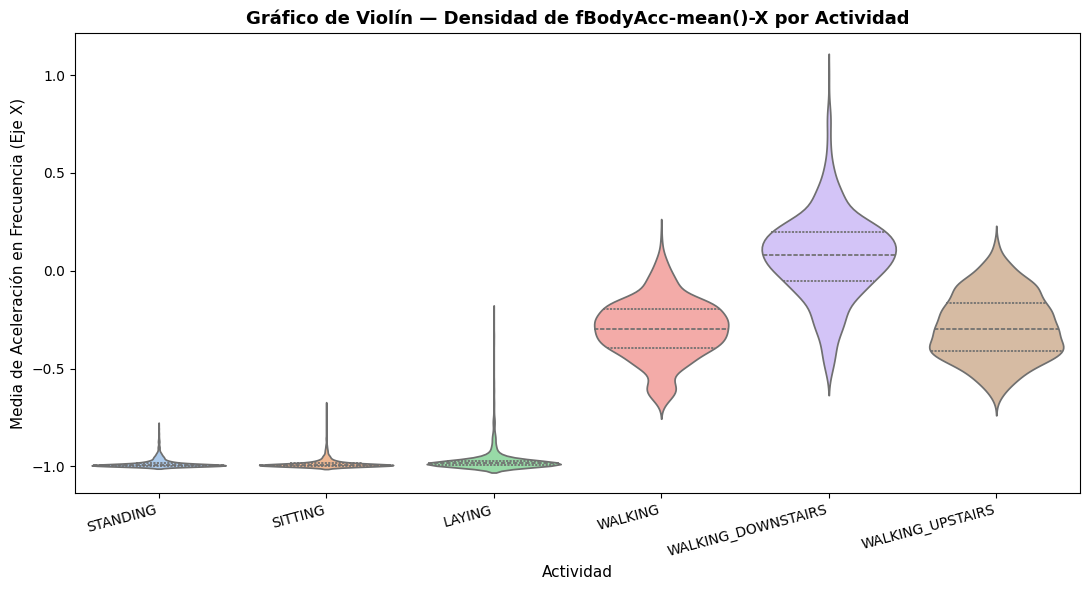

In [24]:
# TODO 16: Visualización adicional a elección del grupo
# Elegimos un Violin Plot para analizar la densidad de probabilidad de 'fBodyAcc-mean()-X'

fig, ax = plt.subplots(figsize=(11, 6))

# Crear el gráfico de violín con líneas de cuartiles internas
sns.violinplot(
    x=y_train_labels.values, 
    y=X_train['fBodyAcc-mean()-X'], 
    ax=ax, 
    palette='pastel',
    inner='quartile'  # Dibuja las líneas de los cuartiles dentro del violín
)

ax.set_title('Gráfico de Violín — Densidad de fBodyAcc-mean()-X por Actividad', fontsize=13, fontweight='bold')
ax.set_xlabel('Actividad', fontsize=11)
ax.set_ylabel('Media de Aceleración en Frecuencia (Eje X)', fontsize=11)

# Rotar etiquetas para que no se superpongan
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.savefig('violin_frecuencia_adicional.png', dpi=300, bbox_inches='tight')
plt.show()


**Análisis:** *[Describir e interpretar la visualización adicional.]*

Análisis de la Visualización Adicional (Gráfico de Violín):

El gráfico de violín muestra la distribución de densidad de la variable fBodyAcc-mean()-X (media de la aceleración del cuerpo en el dominio de la frecuencia para el eje X) a través de las 6 actividades del dataset. Las líneas punteadas internas representan los cuartiles (25%, 50% y 75%).

Interpretación del comportamiento estático: Para las actividades pasivas o estáticas (SITTING, STANDING, LAYING), los violines se presentan extremadamente comprimidos, delgados y achatados en el extremo inferior del rango (cerca de -1.0). Esto tiene un sentido físico directo: al no existir movimiento voluntario del sujeto, las señales en el dominio de la frecuencia no registran energía ni componentes armónicos significativos, concentrando casi la totalidad de las muestras en un único valor basal plano.

Interpretación del comportamiento dinámico: para las actividades activas (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS), los violines se "abren", mostrando formas mucho más anchas, alargadas y con una distribución bimodal o asimétrica. Esto refleja la alta variabilidad y la presencia de picos de frecuencia característicos del ritmo de la caminata. Además, se observa que la actividad WALKING_DOWNSTAIRS (bajar escaleras) desplaza su mediana notablemente más arriba en comparación con la caminata normal, lo que sugiere que el impacto e intensidad gravitacional repetitiva al descender escaleras genera una firma de frecuencia mucho más fuerte y distinguible para los algoritmos de clasificación.

---
## 5. Preparación Final de Datos

In [26]:
# TODO 17: Confirmar que el split train/test viene predefinido (NO crear uno propio)
# El dataset ya provee los índices de sujetos para train/test

# Cargar los identificadores de sujetos usando rutas relativas
sub_train = pd.read_csv(f'{DATA_PATH}/train/subject_train.txt', header=None, names=['subject'])
sub_test  = pd.read_csv(f'{DATA_PATH}/test/subject_test.txt', header=None, names=['subject'])

# Identificar y mostrar los sujetos presentes en cada conjunto
sujetos_train = sorted(sub_train['subject'].unique())
sujetos_test  = sorted(sub_test['subject'].unique())

print('Sujetos únicos en train:', sujetos_train)
print('Sujetos únicos en test: ', sujetos_test)
print(f'Cantidad de sujetos en train: {len(sujetos_train)}')
print(f'Cantidad de sujetos en test:  {len(sujetos_test)}')
print('\nEl split original es por sujeto, garantizando independencia entre sets.')

Sujetos únicos en train: [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
Sujetos únicos en test:  [np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]
Cantidad de sujetos en train: 21
Cantidad de sujetos en test:  9

El split original es por sujeto, garantizando independencia entre sets.


**¿Por qué es importante respetar el split original?** *[Explicar la importancia de no mezclar sujetos entre train y test para evitar data leakage.]*

**INTERPRETACIÓN DE IA, REVISAR** 

Importancia de respetar el split original por sujeto (Prevención de Data Leakage):

* Evita la filtración de datos (Data Leakage): Si ignoráramos esta división y mezcláramos todos los datos para hacer un split aleatorio tradicional (como un train_test_split al azar), registros del mismo sujeto terminarían distribuidos simultáneamente en el conjunto de entrenamiento y en el de prueba. Debido a que cada persona posee características biométricas, ritmos de caminata y formas de moverse únicas e intrínsecas, el modelo memorizaría el "estilo" particular de cada individuo en lugar de aprender el patrón general de la actividad física.
* Garantiza la evaluación de la capacidad de generalización: En un sistema de producción real (como una app de salud o deporte en un smartphone), el software se enfrentará a usuarios completamente nuevos de los cuales nunca ha visto ninguna señal previa. Al separar los conjuntos por bloques de sujetos independientes (21 para entrenar y 9 exclusivamente para evaluar), emulamos con total rigor este escenario del mundo real. Si el modelo obtiene un F1-score alto en el grupo de prueba, confirmamos matemáticamente que aprendió a clasificar la actividad humana y no a identificar las identidades individuales de los voluntarios.

In [27]:
# TODO 18: Exportar variables limpias para la Fase 2
# Asignamos las series con las etiquetas de texto directamente a y_train e y_test
y_train = y_train_labels
y_test  = y_test_labels

# Confirmar que X_train, X_test, y_train, y_test están listos y con las dimensiones correctas
print('Variables disponibles para Fase 2:')
print(f'  X_train: {X_train.shape}')
print(f'  X_test:  {X_test.shape}')
print(f'  y_train: {y_train.shape}')
print(f'  y_test:  {y_test.shape}')

Variables disponibles para Fase 2:
  X_train: (7352, 561)
  X_test:  (2947, 561)
  y_train: (7352,)
  y_test:  (2947,)


* Al ejecutar esta celda, y_train pasó de ser (7352, 1) a (7352,) y x_test de (2947, 561) a (2947,), lo cual confirma que ahora son vectores limpios y encajaran bien con los clasificadores.

---
## 6. Resumen Final de la Fase 1

In [28]:
# Celda de resumen — ejecutar al final para verificar todo
print('=' * 50)
print('RESUMEN FASE 1')
print('=' * 50)
print(f'Dimensiones X_train:   {X_train.shape}')
print(f'Dimensiones X_test:    {X_test.shape}')
print(f'Número de clases:      {len(ACTIVITY_LABELS)}')
print(f'Nombres de clases:     {list(ACTIVITY_LABELS.values())}')
print(f'Valores faltantes:     {X_train.isnull().sum().sum() + X_test.isnull().sum().sum()}')
print(f'Duplicados en train:   {X_train.duplicated().sum()}')
print('=' * 50)

RESUMEN FASE 1
Dimensiones X_train:   (7352, 561)
Dimensiones X_test:    (2947, 561)
Número de clases:      6
Nombres de clases:     ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
Valores faltantes:     0
Duplicados en train:   0


El resumen demuestra que la fase 1 fué exitosa y que el dataset quedó preparado para pasar a la fase 2.